In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path
from dataclasses import dataclass
from anndata import AnnData

In [3]:
# Add parent directory to path
os.chdir("/workspace/")

# Import STAGM
from src.adata_processing import LoadBatch10xAdata, LoadSingle10xAdata
from src.stagm import STAGM

In [4]:
# Dataclass for the configuration of the model
@dataclass
class ModelConfig:
    seed: int
    learning_rate: float
    num_hidden: int
    num_proj_hidden: int
    activation: str
    base_model: str
    num_layers: int
    drop_edge_rate_1: float
    drop_edge_rate_2: float
    drop_feature_rate_1: float
    drop_feature_rate_2: float
    tau: int
    tau_decay: float
    num_epochs: int
    weight_decay: float
    num_clusters: int
    num_gene: int
    num_neigh: int
    k: int
    dropout: float
    order_by_degree: bool
    shuffle_ind: int
    d_state: int
    d_conv: int


# Dataclass for the configuration of the dataset
@dataclass
class DatasetConfig:
    dataset: str
    slide: str
    label: bool
    file_list: list[str]

In [5]:
# Initialize the model configuration with the specified parameters
model_config = ModelConfig(
    seed=39788,
    learning_rate=0.0005,
    num_hidden=64,
    num_proj_hidden=64,
    activation="prelu",
    base_model="GCNConv",
    num_layers=1,
    drop_edge_rate_1 = None,
    drop_edge_rate_2 = None,
    drop_feature_rate_1=0.1,
    drop_feature_rate_2=0.2,
    tau=35,
    tau_decay = None,
    num_epochs=300,
    weight_decay=1e-05,
    num_clusters=7,
    num_gene=3000,
    num_neigh=5,
    k=80,
    dropout=0.0,
    order_by_degree=False,
    shuffle_ind=0,
    d_state=16,
    d_conv=4,
)


# Initialize the dataset configuration with the specified parameters
args = DatasetConfig(
    dataset="DLPFC", 
    slide="151673", 
    label=True,
    file_list=None
)

In [6]:
# Define the base folder and the path to the specific dataset and slide
data_path = Path("./Dataset")
data_path = data_path / args.dataset / args.slide
data_path

PosixPath('Dataset/DLPFC/151673')

In [7]:
# Load the AnnData object using the specified parameters
adata: AnnData = LoadSingle10xAdata(
    path=str(data_path),
    n_neighbors=model_config.num_neigh,
    n_top_genes=model_config.num_gene,
    image_emb=True,
    label=args.label,
).run()

/workspace/src/adata_processing.py:56: FutureWarning: Use `squidpy.read.visium` instead.
  self.adata = sc.read_visium(
/opt/conda/envs/stagm-env/lib/python3.11/site-packages/anndata/_core/anndata.py:1880: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/conda/envs/stagm-env/lib/python3.11/site-packages/anndata/_core/anndata.py:1880: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/opt/conda/envs/stagm-env/lib/python3.11/site-packages/scanpy/preprocessing/_highly_variable_genes.py:178: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}
Calculating edge_probabilities: 100%|██████████| 3611/3611 [00:00<00:00, 63992.02it/s]

adata load done


In [8]:
# Initialize the STAGM model with the specified parameters and assign the loaded AnnData object to it
stagm = STAGM(args=args, config=model_config, single=False)
stagm.adata = adata

In [9]:
# Train the STAGM model
stagm.train()

=== prepare for training ===
=== train ===


100%|██████████| [00:07<00:00, 39.25it/s]


In [10]:
# Evaluate the STAGM model
stagm.eva()

=== load ===

========== Model Diagnostics ==========
  Total parameters:     237,825
  Trainable parameters: 237,825
  Model weight size:    0.91 MB
  Peak GPU memory:      834.88 MB
  Training time:        0m 7.6s  (7.6s total)
  Time per epoch:       25.5 ms

  Loss curve:            first=8.8627  last=8.8365  min=8.8365  max=8.8627

  Embedding shape:      (3611, 64)
  Embedding norm — mean=5.4146  std=2.4094  min=2.4854  max=15.4695

[[-0.19436252 -0.87065613 -0.3727094  ...  0.33142883  0.33638927
  -0.27798274]
 [-0.03060486 -0.17959425  0.47087204 ...  0.6589192  -0.48825356
  -0.1350594 ]
 [ 0.30362353  1.7661011   1.4714386  ...  0.542629   -1.4320496
   0.5423197 ]
 ...
 [ 0.24866015  1.1951072   0.946203   ...  0.20431995 -0.8203119
   0.3514319 ]
 [ 0.3098248   1.6117505   1.3551983  ...  0.47545546 -1.3148532
   0.45899072]
 [-0.15384322 -0.85576767  0.21508756 ...  0.8638996  -0.19375566
  -0.3969816 ]]
embedding generated, go clustering


In [11]:
# Perform clustering using the trained STAGM model
stagm.cluster(args.label)

Searching resolution...
Cluster count 11 is too large, adjusting end downward...
resolution=0.1650, cluster number=10
resolution=0.1600, cluster number=9
resolution=0.1550, cluster number=9
resolution=0.1500, cluster number=9
resolution=0.1450, cluster number=9
resolution=0.1400, cluster number=9
resolution=0.1350, cluster number=9
resolution=0.1300, cluster number=8
resolution=0.1250, cluster number=7
ARI: 0.5540
resolution=0.1200, cluster number=7
ARI: 0.5371
resolution=0.1150, cluster number=7
ARI: 0.5267
resolution=0.1100, cluster number=6
resolution=0.1050, cluster number=6
resolution=0.1000, cluster number=7
ARI: 0.5330
resolution=0.0950, cluster number=7
ARI: 0.5330
resolution=0.0900, cluster number=7
ARI: 0.5330
resolution=0.0850, cluster number=7
ARI: 0.5330
resolution=0.0800, cluster number=5
Best resolution found: (np.float64(0.12499999999999997), 0.5539925548195446)


/workspace/src/clustering.py:57: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, random_state=0, resolution=res)


calculate metric ARI
ARI: 0.5633061922363861
NMI: 0.7101552980585296


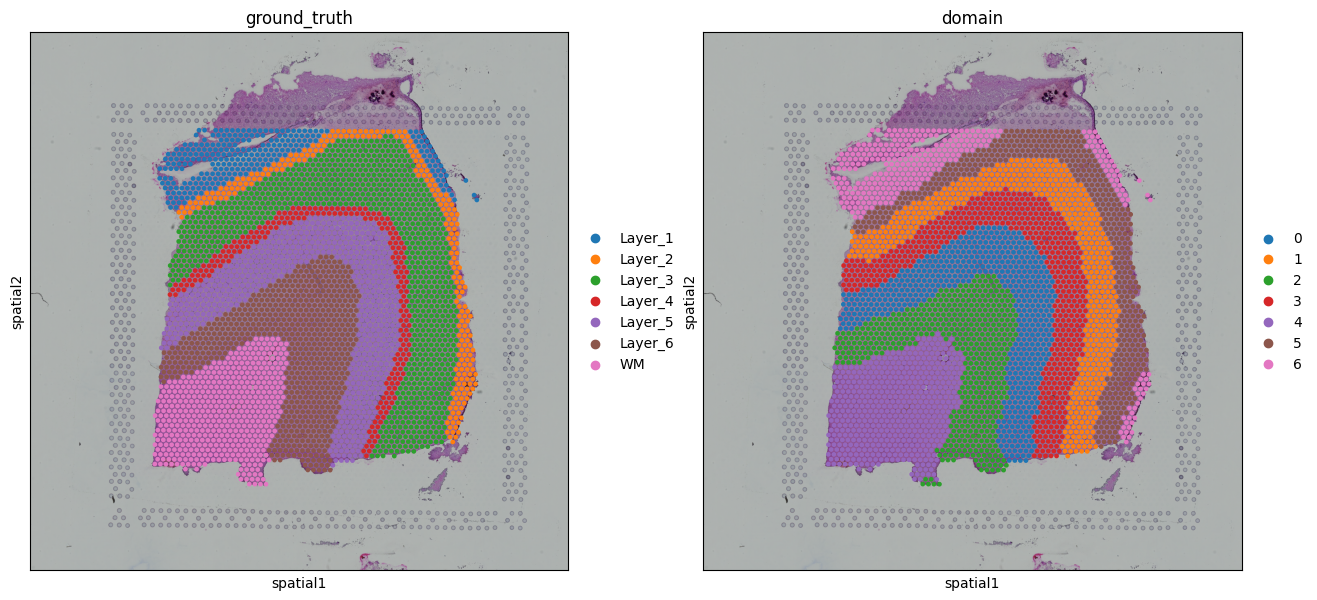

In [12]:
# Draw the spatial visualization of the clusters
stagm.draw_spatial()

start umap


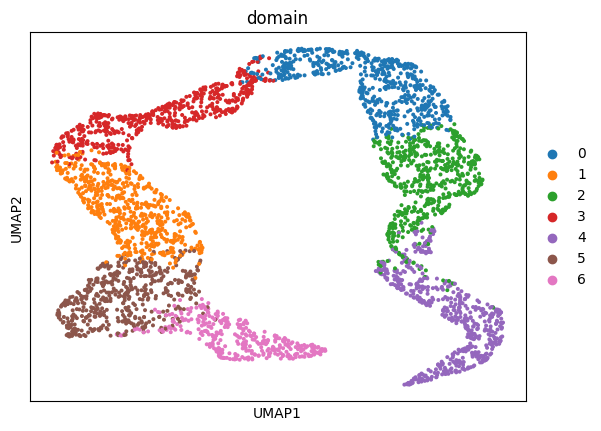

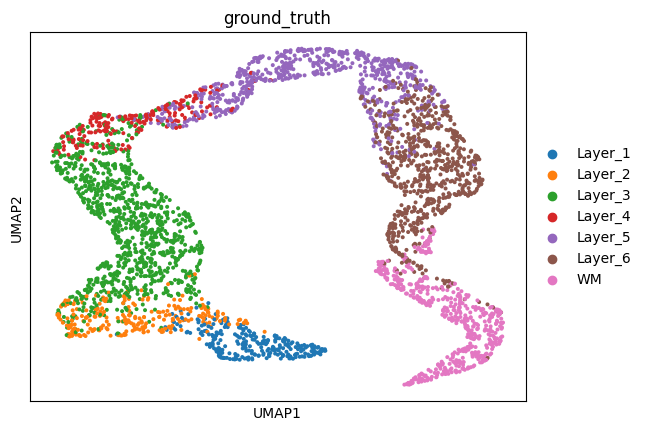

In [13]:
stagm.draw_umap()